In [28]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist

In [29]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [30]:
# print(train_images.shape)

In [31]:
# print(train_labels[1])

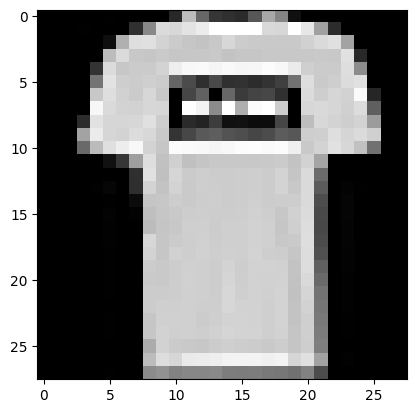

In [32]:
import matplotlib.pyplot as plt

plt.imshow(train_images[1], cmap="gray")

In [33]:
train_images = train_images / 255
test_images = test_images / 255

In [34]:
model = tf.keras.Sequential(
    [
        # trích xuất đặc trưng
        tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        # phân loại
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

/Users/anhngo/.pyenv/versions/3.10.11/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
history = model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8001 - loss: 0.5648
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9021 - loss: 0.2681
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9200 - loss: 0.2158
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9332 - loss: 0.1763
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9493 - loss: 0.1401


In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 903,824 (3.45 MB)

 Trainable params: 301,274 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 602,550 (2.30 MB)

In [37]:
print(history.history)

{'accuracy': [0.8533166646957397, 0.904366672039032, 0.9211166501045227, 0.9345499873161316, 0.9460499882698059], 'loss': [0.40963563323020935, 0.2615628242492676, 0.21340128779411316, 0.17630884051322937, 0.1458950787782669]}


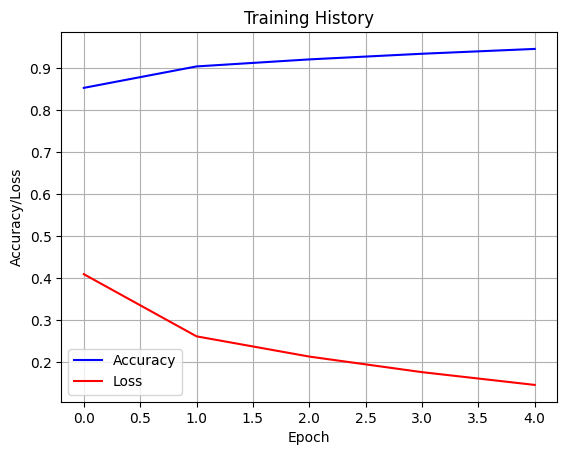

In [38]:
plt.plot(history.history['accuracy'],color='blue')
plt.plot(history.history['loss'],color='red')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Accuracy/Loss')
plt.title('Training History')
plt.legend(['Accuracy','Loss'])
plt.show()

In [41]:
y_pred = model.predict(test_images)
print(y_pred[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[6.8512884e-07 5.2564273e-09 5.4710134e-09 3.6492612e-08 2.8946737e-10
 6.7506546e-05 4.8957244e-10 5.5336335e-04 6.1681355e-08 9.9937820e-01]


In [45]:
y_pred = y_pred.argmax(axis=1)
print(y_pred)

[9 2 1 ... 8 1 5]


In [47]:
print(test_labels)

[9 2 1 ... 8 1 5]


In [43]:
import seaborn as sns

conf_matrix = tf.math.confusion_matrix(test_labels, y_pred)

In [48]:
print(conf_matrix)

tf.Tensor(
[[884   0  15   8   3   1  81   0   8   0]
 [  1 982   0  10   0   0   4   0   3   0]
 [ 17   0 894   7  31   0  48   0   3   0]
 [ 19   3  10 902  31   0  30   0   5   0]
 [  1   1  69  18 836   0  72   0   3   0]
 [  0   0   0   0   0 988   0   6   0   6]
 [ 91   1  56  19  37   0 785   0  11   0]
 [  0   0   0   0   0  12   0 963   0  25]
 [  3   0   1   4   0   2   3   1 986   0]
 [  1   0   0   0   0   6   0  26   0 967]], shape=(10, 10), dtype=int32)


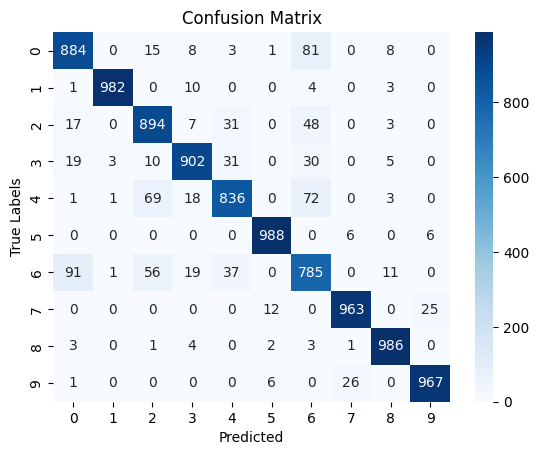

In [51]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
